In [30]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [31]:
df = pd.read_csv('mapped.bed.gz', sep='\t', header=None, compression='gzip')
df.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12
0,2,chr1,90919,91937,chr1:91382-91550|carroll_ctcf_mcf7_v45m`2_GTGG...,16.2951,+,chr1,90838,91006,IH02_00.pairs@15152,168,+
1,2,chr1,90919,91937,chr1:91382-91550|carroll_ctcf_mcf7_v45m`2_GTGG...,16.2951,+,chr1,90846,90998,IH02_04.pairs@4163,152,+
2,2,chr1,90919,91937,chr1:91382-91550|carroll_ctcf_mcf7_v45m`2_GTGG...,16.2951,+,chr1,90851,91000,IH02_04.pairs@4164,149,+
3,2,chr1,90919,91937,chr1:91382-91550|carroll_ctcf_mcf7_v45m`2_GTGG...,16.2951,+,chr1,90850,91014,IH02_00.pairs@15153,164,+
4,2,chr1,90919,91937,chr1:91382-91550|carroll_ctcf_mcf7_v45m`2_GTGG...,16.2951,+,chr1,90900,90965,IH02_00.pairs@15164,65,+


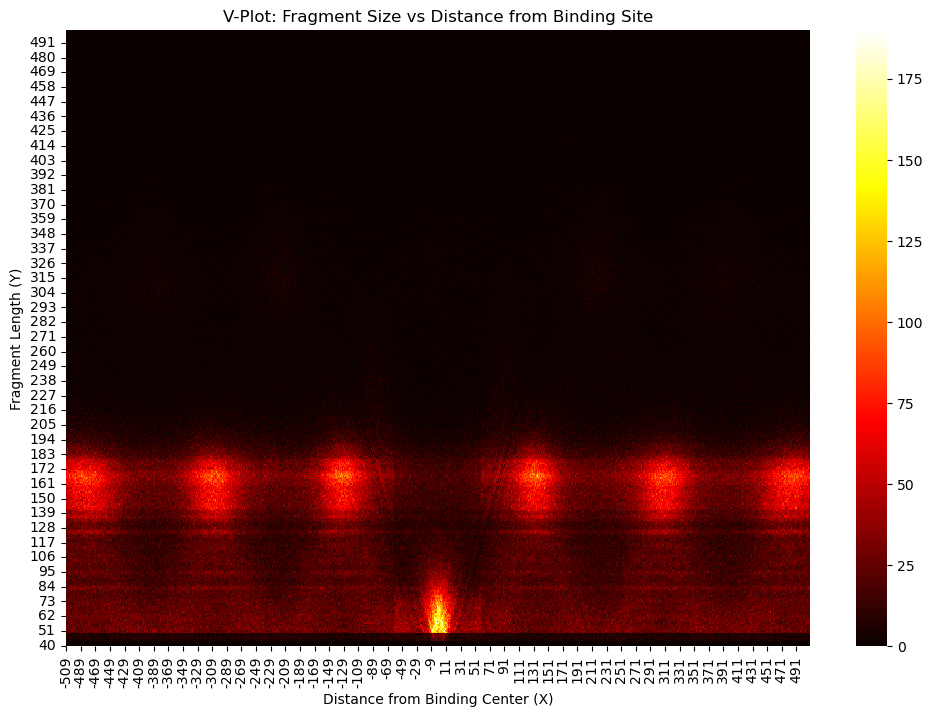

In [32]:
df['C1'] = (df[2] + df[3]) // 2
df['C2'] = (df[8] + df[9]) // 2

df['X'] = df['C2'] - df['C1']
df['Y'] = df[9] - df[8]

# Count occurrences of each (X, Y) pair
cntdf = df[['X', 'Y']].value_counts().reset_index(name='Z')

kr = cntdf.pivot_table(index='Y', columns='X', values='Z', fill_value=0)

plt.figure(figsize=(12, 8))
sns.heatmap(kr, cmap='hot')
plt.title('V-Plot: Fragment Size vs Distance from Binding Site')
plt.xlabel('Distance from Binding Center (X)')
plt.ylabel('Fragment Length (Y)')
plt.gca().invert_yaxis()
plt.show()